In [ ]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.stats import qmc


def maximin_lhs(lower_bounds, upper_bounds, n_samples, n_candidates=1000, rng=None):
    lower_bounds = np.asarray(lower_bounds, dtype=float)
    upper_bounds = np.asarray(upper_bounds, dtype=float)

    if lower_bounds.ndim != 1 or upper_bounds.ndim != 1:
        raise ValueError("lower_bounds and upper_bounds must be 1D arrays.")
    if len(lower_bounds) != len(upper_bounds):
        raise ValueError("lower_bounds and upper_bounds must have the same length.")
    if np.any(upper_bounds <= lower_bounds):
        raise ValueError("Each upper bound must be strictly greater than lower bound.")
    if n_samples < 2:
        raise ValueError("n_samples must be at least 2.")
    if n_candidates < 1:
        raise ValueError("n_candidates must be at least 1.")

    d = len(lower_bounds)

    # make one numpy generator for reproducibility
    base_rng = np.random.default_rng(rng)

    best_min_dist = -np.inf
    X_best_unit = None

    for _ in range(n_candidates):
        # draw an integer seed for this candidate
        seed_i = int(base_rng.integers(0, 2**32 - 1))

        sampler = qmc.LatinHypercube(d=d, seed=seed_i)
        X_unit = sampler.random(n=n_samples)

        min_dist = pdist(X_unit).min()

        if min_dist > best_min_dist:
            best_min_dist = min_dist
            X_best_unit = X_unit.copy()

    X_best = qmc.scale(X_best_unit, lower_bounds, upper_bounds)
    return X_best

In [53]:
import numpy as np
import matplotlib.pyplot as plt


def plot_all_2d_projections(X, labels=None, diag_mode="label", figsize=None):
    """
    Plot all pairwise 2D projections of a sample matrix in a d x d grid.

    Parameters
    ----------
    X : ndarray of shape (n_samples, d)
        Sample matrix.
    labels : list of str, optional
        Names of dimensions. If None, uses x0, x1, ..., x(d-1).
    diag_mode : {"label", "hist", "empty"}, optional
        What to show on the diagonal:
          - "label": write the variable name
          - "hist": show a histogram of that variable
          - "empty": leave blank
    figsize : tuple, optional
        Figure size. If None, chosen automatically.

    Returns
    -------
    fig, axes
        Matplotlib figure and axes array.
    """
    X = np.asarray(X, dtype=float)

    if X.ndim != 2:
        raise ValueError("X must be a 2D array of shape (n_samples, d).")

    n_samples, d = X.shape

    if d < 2:
        raise ValueError("X must have at least 2 dimensions.")

    if labels is None:
        labels = [f"x{i}" for i in range(d)]
    if len(labels) != d:
        raise ValueError("labels must have length equal to number of dimensions.")

    if figsize is None:
        figsize = (3 * d, 3 * d)

    fig, axes = plt.subplots(d, d, figsize=figsize, squeeze=False)

    for i in range(d):
        for j in range(d):
            ax = axes[i, j]

            if i == j:
                if diag_mode == "label":
                    ax.text(
                        0.5, 0.5, labels[i],
                        ha="center", va="center", fontsize=12,
                        transform=ax.transAxes
                    )
                    ax.set_xticks([])
                    ax.set_yticks([])
                elif diag_mode == "hist":
                    ax.hist(X[:, j], bins=min(15, n_samples))
                elif diag_mode == "empty":
                    ax.set_xticks([])
                    ax.set_yticks([])
                else:
                    raise ValueError("diag_mode must be 'label', 'hist', or 'empty'.")

            else:
                ax.scatter(X[:, j], X[:, i], s=20)

            # Only label outer axes to reduce clutter
            if i == d - 1:
                ax.set_xlabel(labels[j])
            else:
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(labels[i])
            else:
                ax.set_yticklabels([])

    plt.tight_layout()
    return fig, axes

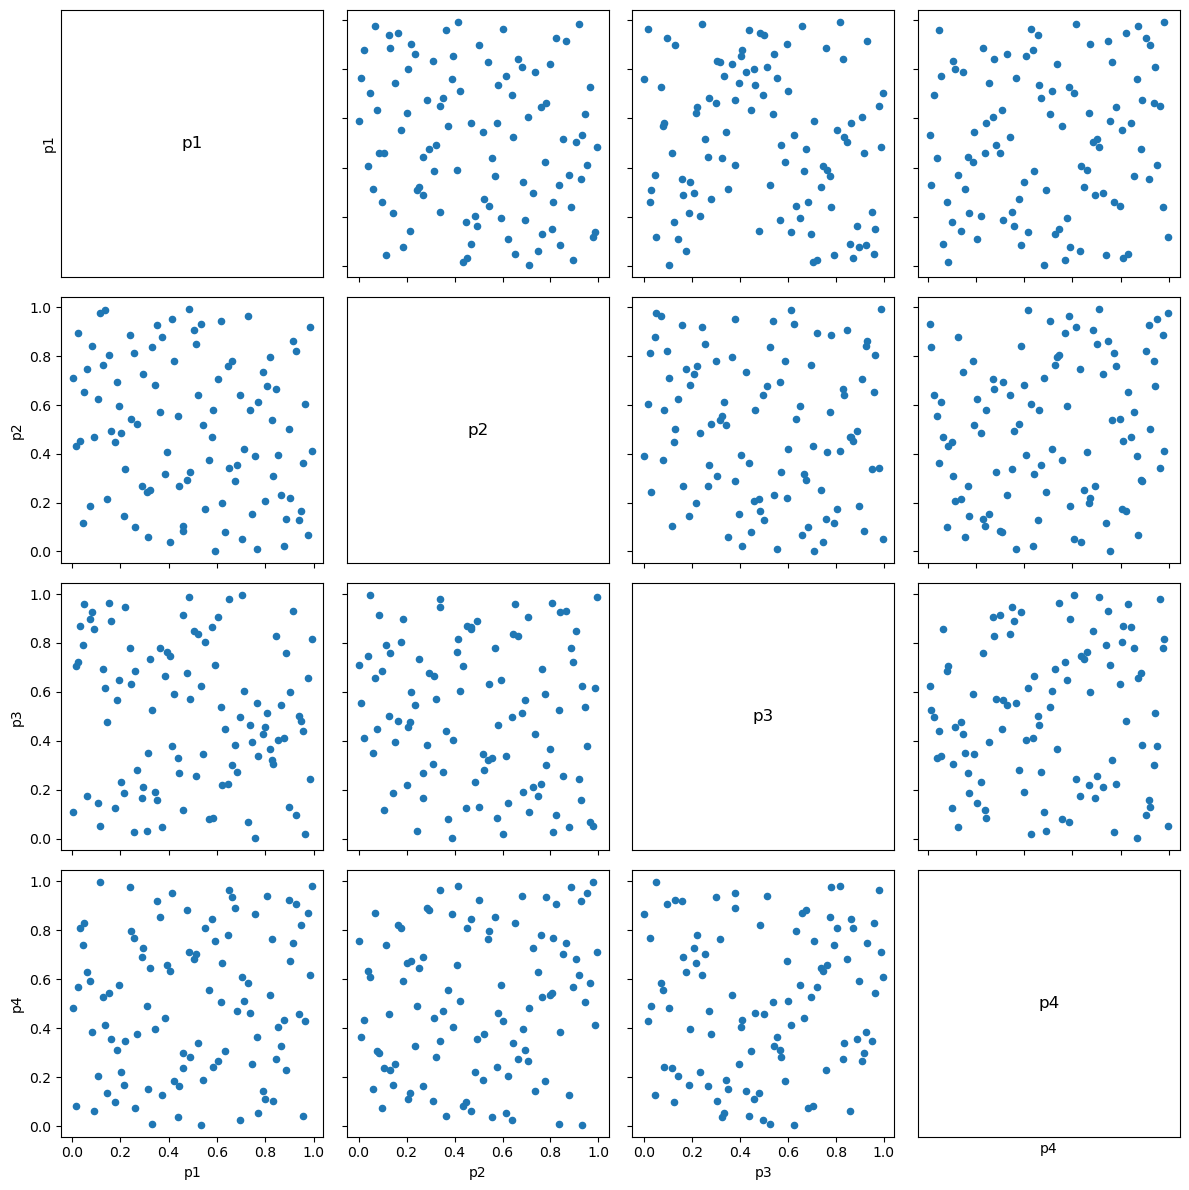

In [57]:
X = maximin_lhs(
    lower_bounds=[0, 0, 0, 0],
    upper_bounds=[1, 1, 1, 1],
    n_samples=100,
    n_candidates=5000,
    rng=42
)

plot_all_2d_projections(
    X,
    labels=["p1", "p2", "p3", "p4"],
    diag_mode="label"
)

plt.show()

In [37]:
X

array([[8.05248967e-01, 5.59460408e-01, 6.57081352e-01, 9.18695996e-01],
       [4.79068630e-02, 4.08967158e-01, 7.90774642e-01, 1.33846473e-01],
       [8.56010531e-01, 9.47192472e-01, 4.79254726e-02, 7.91792929e-01],
       [2.99894690e-01, 6.65781436e-01, 9.45046169e-01, 8.81172274e-01],
       [7.17604658e-01, 3.82275863e-01, 4.71141587e-01, 4.00089768e-01],
       [2.23871599e-02, 1.99119858e-01, 5.80852710e-01, 8.13528620e-01],
       [9.98564865e-01, 5.27887562e-01, 4.98355370e-01, 2.06730269e-01],
       [5.98527064e-01, 6.25614254e-01, 8.93568807e-01, 4.39214069e-02],
       [4.51568305e-01, 4.14705840e-01, 3.41326828e-02, 5.71777067e-01],
       [7.51539667e-01, 5.33035886e-01, 6.86474995e-01, 5.67314964e-01],
       [4.22272054e-01, 1.34596393e-01, 9.83118065e-01, 1.97913316e-01],
       [2.57753429e-01, 1.47253615e-01, 1.10937938e-01, 5.91150890e-01],
       [2.71201407e-01, 7.66039939e-01, 6.33408028e-01, 2.30015168e-01],
       [7.77691905e-01, 8.77259125e-01, 3.00799197e